<a href="https://colab.research.google.com/github/Yashcode007/masters_in_ai/blob/deep_learning_wb_84520/convolution_5_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

Conv1D is usually for the time series data(over some sort of signal) .
Conv2D is usually for image data
Conv3D is usually for the volume data or video data(which has 3rd dimension)

In [2]:
net = torch.nn.Conv2d(1,16,3,1,(3-1)//2)

In [3]:
print(net)

Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


In [4]:
x = torch.randn(1,1,28,28)

In [5]:
print(x.shape)

torch.Size([1, 1, 28, 28])


In [6]:
y = net(x)

In [7]:
print(y)

tensor([[[[-1.7274e-01, -1.9955e+00,  3.8218e-01,  ...,  1.2561e-03,
           -4.1603e-01, -7.7881e-02],
          [ 8.6360e-01,  3.4164e-01,  6.2586e-01,  ..., -2.5350e-01,
            4.2979e-01,  4.1066e-01],
          [-4.9938e-01,  9.4776e-01, -1.0088e-01,  ..., -1.7268e-01,
           -6.7181e-01,  6.4166e-02],
          ...,
          [ 3.6448e-01,  1.3088e+00,  5.4185e-01,  ..., -1.2121e+00,
           -8.0926e-01, -5.0500e-04],
          [-3.0754e-01,  3.5326e-01, -1.7485e+00,  ...,  1.3456e+00,
            2.1794e-01,  5.7301e-01],
          [ 1.1644e+00, -4.2817e-01, -5.7812e-02,  ..., -6.8683e-01,
           -1.0007e+00,  8.8360e-01]],

         [[-7.9047e-01, -2.1066e-02, -8.2819e-02,  ..., -2.9453e-01,
           -3.1183e-01,  1.3342e-01],
          [-1.2146e-01, -4.3703e-01,  3.0932e-01,  ...,  6.8300e-01,
           -3.2875e-01,  3.1708e-01],
          [-1.6342e-01,  1.1564e+00, -3.4900e-01,  ..., -3.6614e-01,
            8.0588e-02, -2.4855e-02],
          ...,
     

In [8]:
print(y.shape)

torch.Size([1, 16, 28, 28])


In [12]:
class ConvNet(torch.nn.Module):
  def __init__(self , layers=[16,32,64],kernel_size=3, stride=1):
    super().__init__()
    cnn_layers = []
    c1 = 1
    for c2 in layers:
      cnn_layers.append(torch.nn.Conv2d(c1, c2, kernel_size, stride,(kernel_size-1)//2))
      cnn_layers.append(torch.nn.ReLU())
      c1 = c2
    cnn_layers.append(torch.nn.Conv2d(c1,1,kernel_size=1))
    self.network = torch.nn.Sequential(*cnn_layers)

  def forward(self , x):
    return self.network(x)

In [13]:
net = ConvNet()
print(net)

ConvNet(
  (network): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(64, 1, kernel_size=(1, 1), stride=(1, 1))
  )
)


In [14]:
print(net(x))

tensor([[[[0.0530, 0.0666, 0.0502, 0.0552, 0.0631, 0.0417, 0.0290, 0.0174,
           0.0478, 0.0342, 0.0512, 0.0740, 0.0146, 0.0618, 0.0222, 0.0571,
           0.0558, 0.0458, 0.0464, 0.0410, 0.0246, 0.0463, 0.0389, 0.0202,
           0.0447, 0.0587, 0.0575, 0.0616],
          [0.0754, 0.0986, 0.0485, 0.1360, 0.0530, 0.1190, 0.0641, 0.0889,
           0.0821, 0.1299, 0.0626, 0.0478, 0.0988, 0.0601, 0.0821, 0.1444,
           0.0545, 0.0711, 0.0727, 0.0792, 0.0949, 0.0835, 0.0862, 0.0706,
           0.0907, 0.0884, 0.0472, 0.0590],
          [0.0399, 0.1009, 0.0981, 0.0408, 0.0595, 0.0860, 0.0632, 0.0507,
           0.0672, 0.0383, 0.0901, 0.0494, 0.0548, 0.1127, 0.0717, 0.0781,
           0.0680, 0.0970, 0.0468, 0.1151, 0.0384, 0.0861, 0.0337, 0.1031,
           0.0609, 0.0941, 0.0702, 0.0765],
          [0.0709, 0.0534, 0.0982, 0.0865, 0.0865, 0.0754, 0.0590, 0.0395,
           0.0520, 0.0723, 0.0524, 0.0705, 0.0560, 0.0554, 0.0557, 0.0620,
           0.0513, 0.0663, 0.0743, 0.0747, 

In [15]:
net(x).shape

torch.Size([1, 1, 28, 28])

In [20]:
net_2 = ConvNet()

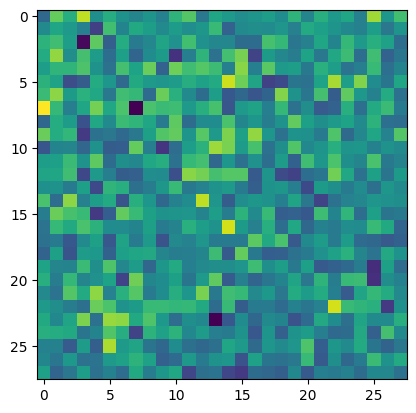

In [21]:
from matplotlib import pyplot as plt

x = torch.randn(1,1,28,28)
net = ConvNet()
y = net(x)
plt.imshow(y[0,0].detach().numpy())

Receptive Field is what output is built by what input

For Visualisation of the Receptive Field

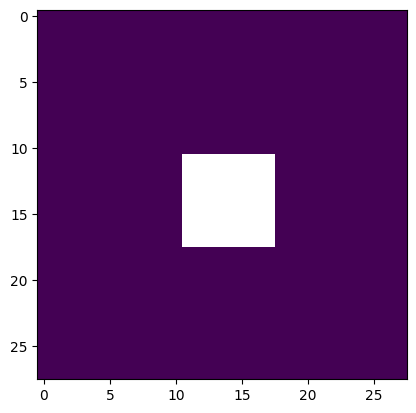

In [28]:
from matplotlib import pyplot as plt

x = torch.randn(1,1,28,28,requires_grad=True)
net = ConvNet(stride=1)
y = net(x)
z = y.new_zeros(y.shape)
z[0,0,z.shape[2]//2,z.shape[3]//2] = float('NaN')

(y * z).sum().backward()

plt.imshow(x.grad[0,0].detach().numpy())